In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set figure size for better readability
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# Load the dataset
file_path = 'cartoon_popularity_data.csv' # Fill here with the path to your dataset

# Check if the file exists
try:
    with open(file_path, 'r') as f:
        pass
except FileNotFoundError:
    print(f"File {file_path} not found. Please check the path and try again.")
    exit()

# Read the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print(f"Dataset shape: {df.shape}")
df.head(20)

Dataset shape: (10000, 5)


,Character,Country,Popularity_Score,Avg_Episodes_Watched_Per_Year,Merchandise_Revenue_MillionUSD
0,Shinchan,Canada,74.06677446676758,80,3.949924724368964
1,Paw Patrol,France,80.58192518328079,48,22.31606244865129
2,SpongeBob SquarePants,Russia,37.853437720835345,127.5,258.92694939230086
3,Motu Patlu,UK,83.41104266407503,50,27.430804382862224
4,Mr Bean,Egypt,76.83135775923722,9,40.715313915210565
5,Mr Bean,Russia,74.49889820916066,100,89.88446547664522
6,Shinchan,China,42.215996679968406,53,47.33693889068305
7,Shinchan,France,29.350012864742613,5,87.70944109744121
8,Motu Patlu,Australia,53.937903011962575,72,60.295513861562675
9,Motu Patlu,Saudi Arabia,48.59904633166138,73,13.710754985476516


In [2]:
#part01:exploratory data analysis
#Task1.1
print(df.shape)

(10000, 5)


In [3]:
print(df.dtypes)

Character                         str
Country                           str
Popularity_Score                  str
Avg_Episodes_Watched_Per_Year     str
Merchandise_Revenue_MillionUSD    str
dtype: object


In [4]:
print(df.describe())
print(df.drop(columns="Character"))

       Character    Country Popularity_Score Avg_Episodes_Watched_Per_Year  \
count      10000       9553             9558                          9933   
unique        50         41             9488                           492   
top     Doraemon  Australia          Unknown                            13   
freq         929        430               71                            93   

       Merchandise_Revenue_MillionUSD  
count                           10000  
unique                          10000  
top                 3.949924724368964  
freq                                1  
        Country    Popularity_Score Avg_Episodes_Watched_Per_Year  \
0        Canada   74.06677446676758                            80   
1        France   80.58192518328079                            48   
2        Russia  37.853437720835345                         127.5   
3            UK   83.41104266407503                            50   
4         Egypt   76.83135775923722                             

In [5]:
#no of missing values in each column
print(df.isna().sum())

Character                           0
Country                           447
Popularity_Score                  442
Avg_Episodes_Watched_Per_Year      67
Merchandise_Revenue_MillionUSD      0
dtype: int64


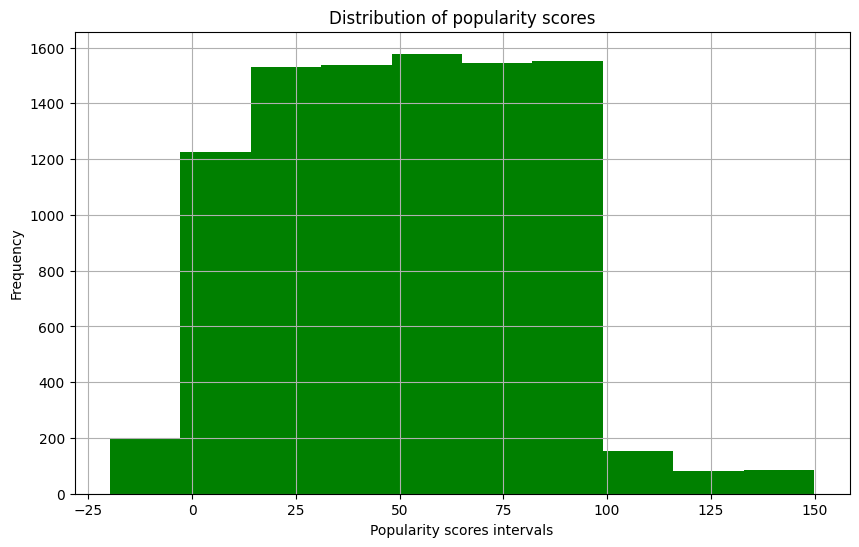

In [6]:
#Task 1.2 data visualization
newseries=df["Popularity_Score"].dropna()
newSeries=pd.to_numeric(newseries,errors="coerce")
plt.hist(newSeries,color="g")
plt.title("Distribution of popularity scores")
plt.xlabel("Popularity scores intervals")
plt.ylabel("Frequency")
plt.show()

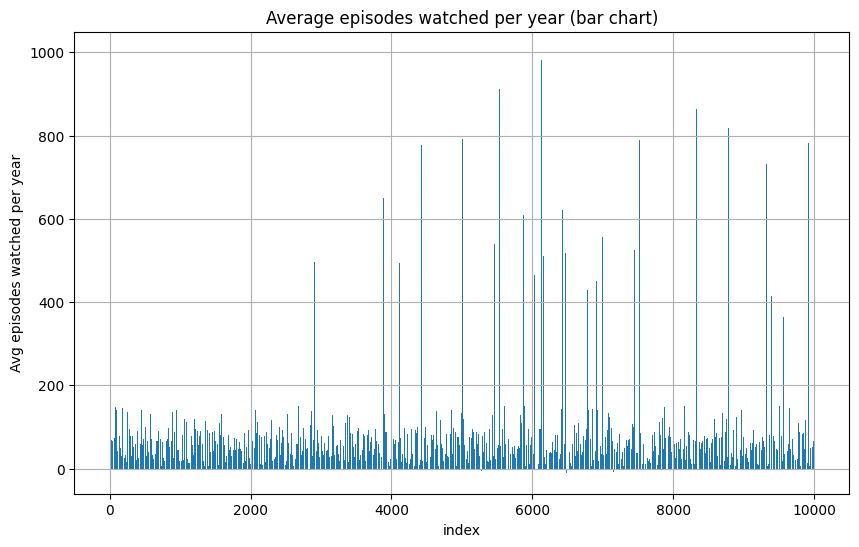

In [7]:
df["Avg_Episodes_Watched_Per_Year"]=pd.to_numeric(df["Avg_Episodes_Watched_Per_Year"],errors="coerce")
plt.bar(df.index,df['Avg_Episodes_Watched_Per_Year'])
plt.title("Average episodes watched per year (bar chart)")
plt.xlabel("index")
plt.ylabel("Avg episodes watched per year")
plt.show()



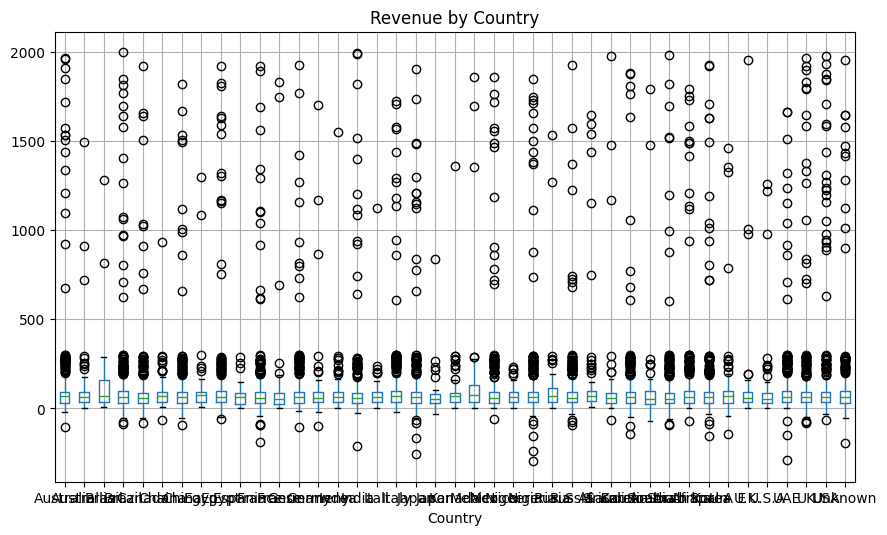

In [8]:
df["Merchandise_Revenue_MillionUSD"]=pd.to_numeric(df["Merchandise_Revenue_MillionUSD"],errors="coerce")
df.boxplot(column='Merchandise_Revenue_MillionUSD', by='Country')
plt.title("Revenue by Country")
plt.suptitle("")   # removes extra automatic title
plt.show()


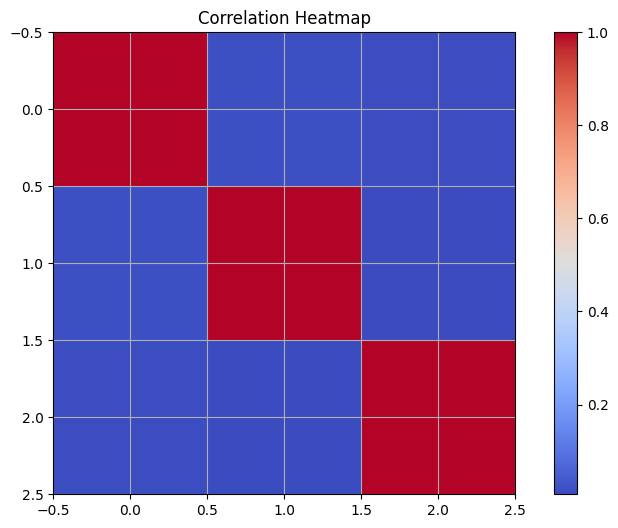

In [9]:
df['Popularity_Score']=pd.to_numeric(df["Popularity_Score"],errors="coerce")
newdf=df.drop(columns=["Character",'Country'])
plt.imshow(newdf.corr(),cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

# Task 1.3: Identifying Data Issues

## Data Quality Issues Found

After exploring the dataset, several data quality issues were identified.

### 1. Inconsistent Text Formatting

Some character names and country names contained:

* Extra spaces
* Different capitalization styles

### Category

Inconsistent Formats

### Impact on Analysis

These inconsistencies can create duplicate categories and incorrect grouping during analysis and visualization. For example, "USA" and "Usa" may be treated as different countries.

---

### 2. Missing or Invalid Numerical Values

Some numerical columns contained:

* Empty values
* Incorrect formats
* Non-numeric values stored as text

### Category

Missing Values / Incorrect Data Types

### Impact on Analysis

Missing or invalid values can cause errors during calculations, plotting, and statistical analysis. Machine learning models may also fail if numerical columns contain text values.

---

### 3. Presence of Outliers

Certain numerical columns such as:

* Popularity_Score
* Merchandise_Revenue_MillionUSD
* Avg_Episodes_Watched_Per_Year

contained unusually high or low values.

### Category

Outliers

### Impact on Analysis

Outliers can heavily affect:

* Mean and standard deviation
* Correlation analysis
* Model performance
* Data visualization

They may lead to misleading conclusions if not handled properly.

---

### 4. Inconsistent Data Types

Some numerical columns were stored as object/string type instead of numeric type.

### Category

Data Type Issues

### Impact on Analysis

This prevents mathematical operations and causes errors in plotting, normalization, and statistical analysis.

---

### 5. Unencoded Categorical Variables

Columns such as Character and Country were categorical and not encoded.

### Category

Categorical Data Issue

### Impact on Analysis

Many machine learning algorithms require numerical input. Without encoding, categorical variables cannot be used effectively for predictive analysis.

---

## Conclusion

The dataset required preprocessing before analysis. Cleaning the data improved consistency, reduced errors, and prepared the dataset for accurate visualization, statistical analysis, and machine learning tasks.


In [10]:
#Part 2:data cleaning and preprocesssing 
# Task 2.1 fiiling missing values 
df[["Character","Country"]]=(df[["Character","Country"]].fillna(df[["Character","Country"]].mode))
print(df.isna().sum())

Character                           0
Country                             0
Popularity_Score                  513
Avg_Episodes_Watched_Per_Year     144
Merchandise_Revenue_MillionUSD    168
dtype: int64


In [11]:
df[["Avg_Episodes_Watched_Per_Year","Merchandise_Revenue_MillionUSD","Popularity_Score"]]=(df[["Avg_Episodes_Watched_Per_Year","Merchandise_Revenue_MillionUSD","Popularity_Score"]].fillna(df[["Avg_Episodes_Watched_Per_Year","Merchandise_Revenue_MillionUSD","Popularity_Score"]].mean()))
print(df.isna().sum())

Character                         0
Country                           0
Popularity_Score                  0
Avg_Episodes_Watched_Per_Year     0
Merchandise_Revenue_MillionUSD    0
dtype: int64


In [12]:
#task 2.2
df['Character'] = (
    df['Character']
    .str.strip()
    .str.title()
    .str.replace(r'\s+', ' ', regex=True)
)

# Clean country names
df['Country'] = (
    df['Country']
    .str.strip()
    .str.title()
)

df['Country'] = df['Country'].replace({
    'Usa': 'USA',
    'U.S.A': 'USA',
    'Unted States': 'United States',
    'Indai': 'India'
})

print(df.head())

               Character Country  Popularity_Score  \
0               Shinchan  Canada         74.066774   
1             Paw Patrol  France         80.581925   
2  Spongebob Squarepants  Russia         37.853438   
3             Motu Patlu      Uk         83.411043   
4                Mr Bean   Egypt         76.831358   

   Avg_Episodes_Watched_Per_Year  Merchandise_Revenue_MillionUSD  
0                           80.0                        3.949925  
1                           48.0                       22.316062  
2                          127.5                      258.926949  
3                           50.0                       27.430804  
4                            9.0                       40.715314  


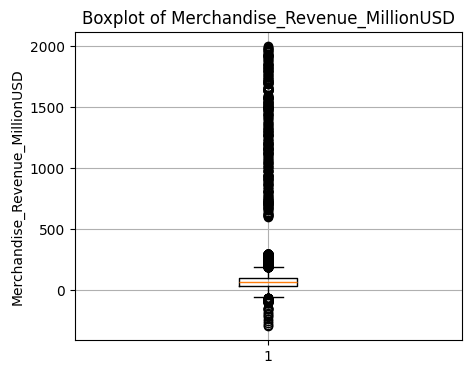

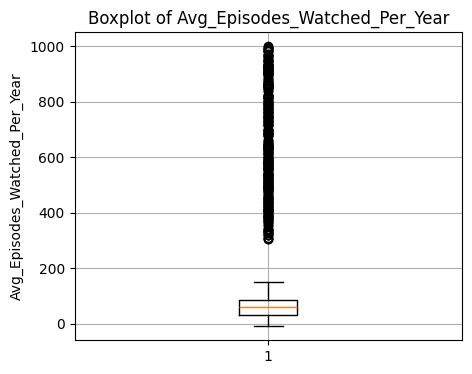

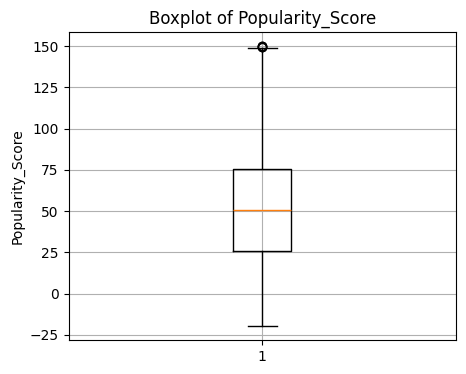

In [13]:
#task 2.3
#detecting outliers using boxplot 

import matplotlib.pyplot as plt
numerical_cols = ['Merchandise_Revenue_MillionUSD','Avg_Episodes_Watched_Per_Year','Popularity_Score']
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [14]:
#Detect Outliers Using IQR Method\
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Number of outliers: {len(outliers)}")


Merchandise_Revenue_MillionUSD
Number of outliers: 1299

Avg_Episodes_Watched_Per_Year
Number of outliers: 365

Popularity_Score
Number of outliers: 4


In [15]:
#Handling Outliers 
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

In [16]:
# TASK 2.4 — DATA TRANSFORMATION
# =========================================================

# ---------- Standardization ----------

for col in numerical_cols:

    mean = df[col].mean()

    std = df[col].std()

    df[col] = (df[col] - mean) / std

# =========================================================
# CREATE DERIVED FEATURES
# =========================================================

# Revenue per episode watched

df['Revenue_Per_Episode'] = (
    df['Merchandise_Revenue_MillionUSD'] /
    df['Avg_Episodes_Watched_Per_Year']
)

# Popularity to revenue ratio

df['Popularity_Revenue_Ratio'] = (
    df['Popularity_Score'] /
    df['Merchandise_Revenue_MillionUSD']
)

# =========================================================
# ENCODE CATEGORICAL VARIABLES
# =========================================================

df = pd.get_dummies(
    df,
    columns=['Character', 'Country'],
    drop_first=True
)

# =========================================================
# FINAL OUTPUT
# =========================================================

print("\nFinal Dataset Info:\n")

print(df.info())

print("\nFirst 5 Rows:\n")

print(df.head())


Final Dataset Info:

<class 'pandas.DataFrame'>
Index: 8386 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Popularity_Score                 8386 non-null   float64
 1   Avg_Episodes_Watched_Per_Year    8386 non-null   float64
 2   Merchandise_Revenue_MillionUSD   8386 non-null   float64
 3   Revenue_Per_Episode              8386 non-null   float64
 4   Popularity_Revenue_Ratio         8386 non-null   float64
 5   Character_Mickey Mouse           8386 non-null   bool   
 6   Character_Motu Patlu             8386 non-null   bool   
 7   Character_Mr Bean                8386 non-null   bool   
 8   Character_Paw Patrol             8386 non-null   bool   
 9   Character_Peppa Pig              8386 non-null   bool   
 10  Character_Pokemon                8386 non-null   bool   
 11  Character_Shinchan               8386 non-null   bool   
 12  Character_Spon

# Part 4: Conclusion and Documentation

## Task 4.1: Summary of Findings

### Initial State of the Data

The dataset initially contained several inconsistencies and quality issues. Some text columns had extra spaces and inconsistent capitalization. Certain country names were spelled differently, leading to duplicate categories. Numerical columns also contained outliers that could negatively affect analysis and visualization.

### Issues Identified

The following issues were identified in the dataset:

* Inconsistent formatting in character names
* Country name spelling inconsistencies
* Presence of outliers in numerical columns
* Numerical columns stored in incorrect formats
* Categorical variables not encoded for analysis

### Methods Used to Address the Issues

#### Data Cleaning

* Used string functions such as `strip()` and `title()` to standardize text formatting
* Corrected country name spellings using `replace()`

#### Outlier Detection and Handling

* Used boxplots to visually identify outliers
* Applied the IQR (Interquartile Range) method to statistically detect outliers
* Handled outliers using the capping method to limit extreme values within acceptable ranges

#### Data Transformation

* Standardized numerical features using mean and standard deviation normalization
* Created derived features such as:

  * Revenue_Per_Episode
  * Popularity_Revenue_Ratio
* Applied one-hot encoding to categorical variables using `pd.get_dummies()`

### Final State of the Cleaned Dataset

The final cleaned dataset is more consistent, reliable, and suitable for analysis and machine learning tasks. Text inconsistencies were removed, numerical columns were standardized, and categorical variables were properly encoded.

### Insights Gained

During preprocessing, it was observed that:

* Some cartoons generated significantly higher merchandise revenue than others
* Certain countries appeared more frequently in the dataset
* Outliers had a noticeable impact on revenue-related columns
* Feature engineering helped reveal relationships between popularity and revenue


In [18]:
# =========================================================
# SAVE CLEANED DATASET
# =========================================================

df_cleaned = df.copy()

df_cleaned.to_csv(
    'cartoon_popularity_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
